In [1]:
using ITensors, ITensorMPS, LinearAlgebra

In [2]:
"""
Functions for initializing the whip circuit
"""
function make_1d_whip_gates(nbits::Int64, theta::Float64, sites::Vector{Index{Int64}}, use_loop_op=true)
    if nbits == 2
        angles = Array([theta])
        indices = [(1,nbits)]
    else
        if use_loop_op
            indices = [(1,nbits)]
            angles = zeros(Float64, nbits)
            angles[1] = theta/2
            angles[2:end-1] .= theta
            angles[end] = theta/2
        else
            indices = []
            angles = zeros(Float64, nbits-1)
            angles .= theta
        end
        for i in 1:nbits-1
            push!(indices, (i,i+1))
        end
    end
    @assert length(angles) == length(indices)
    gates = ITensor[]
    for i in eachindex(indices)
        s_1, s_2 = indices[i]
        a = angles[i]
        T2 = op("Z",sites[s_1]) * op("Y",sites[s_2])
        G = exp(-1im * a / 2 * T2) # need divided by 2
        push!(gates, G)
    end
    return gates
end

make_1d_whip_gates

In [3]:
# ==== ====
"""
Functions for projecting back to the computational basis
"""
function get_statevector_from_mps(nbits::Int, mps::MPS)
    _sites = siteinds(mps)
    # statevec = zeros(typeof(mps[1][1]), 2^nbits)
    statevec = zeros(ComplexF64, 2^nbits)
    for i in eachindex(statevec)
        bit = string(i-1, base = 2, pad = nbits) # index to basis state
        # j = parse(Int, join(new_bit), base=2) + 1# basis state to index
        # construct mps based on bitstring
        bitstring = split(bit, "")
        imps = MPS(_sites, bitstring)
        # calculate the inner product
        val = inner(imps, mps)
        statevec[i] = val
    end
    statevec
end

get_int(s) = parse(Int, s, base=2)
get_bit(idx, n) = string(idx, base=2, pad=n)

"""
Find the nonzero bitstring
"""
function check_ground_state_configuration(mps::MPS)
    println(inner(mps,mps))
    nbits = length(mps)
    if nbits >= 20
        return print("System size is too large")
    end
    psivec = get_statevector_from_mps(nbits, mps)
    nz_loc = []
    for i in eachindex(psivec)
        if isapprox(psivec[i], 0, atol=1E-14)
            continue
        else
            push!(nz_loc, i)
        end
    end
    get_bit.(nz_loc.-1, nbits), psivec[nz_loc]
end

"""
Entanglement entropy
https://docs.itensor.org/ITensorMPS/stable/examples/MPSandMPO.html#Computing-the-Entanglement-Entropy-of-an-MPS
"""
function entanglement_entropy_svd(mps::MPS, cut_bond)
    b = cut_bond #Int(N/2)
    mps_copy = orthogonalize(mps, b)
    # The reduced density matrix eigenvalues are the squares of the
    # Schmidt coefficients, which are the singular values
    # U,S,V = svd(mps_copy[b], (linkinds(mps_copy, b-1)..., siteinds(mps_copy, b)...))
    U,S,V = svd(mps_copy[b], (siteinds(mps_copy, b)...,linkinds(mps_copy, b-1)...))
    # Extract Schmidt coefficients (singular values)
    S_vN = 0.0
    for n=1:dim(S, 1)
      p = S[n,n]^2   # Probability = |coefficient|^2
    #   if p > 1E-16 # Avoid log(0)
          S_vN -= p * log2(p)
    #   end
    end
    S_vN
end

entanglement_entropy_svd

In [4]:
# system parameters
N = 6
use_loop_op = true
# whip angle
theta = pi/3
# svd cutoff
l_cutoff = 1E-8
# Initialize the sites
sites = siteinds("Qubit", N)
# Create the quantum circuit gates
gates = make_1d_whip_gates(N, theta, sites, use_loop_op);

In [5]:
# 000 state
states = ["0" for n in 1:N]
ket0 = MPS(sites, states);
# +++ state
states = ["+" for n in 1:N]
psi0 = MPS(sites, states);

In [6]:
# apply gates
psi = apply(gates, psi0; cutoff=l_cutoff);
println(" ", maxlinkdim(psi))

 4


In [ ]:
L = psi[2] 
Ldag = dag(prime(psi[2], commoninds(psi[2],psi[3])))
display(inds(L))
display(inds(Ldag))
array(L*Ldag)

((dim=2|id=233|"Qubit,Site,n=2"), (dim=2|id=30|"Link,n=1"), (dim=4|id=1|"Link,n=1"))

((dim=2|id=233|"Qubit,Site,n=2"), (dim=2|id=30|"Link,n=1"), (dim=4|id=1|"Link,n=1")')

4×4 Matrix{ComplexF64}:
          1.0+0.0im  -8.24972e-17+0.0im  …   2.91086e-16+0.0im
 -8.24972e-17+0.0im           1.0+0.0im     -7.70214e-17+0.0im
 -1.62212e-17+0.0im   1.30669e-17+0.0im      5.62563e-16+0.0im
  2.91086e-16+0.0im  -7.70214e-17+0.0im              1.0+0.0im

In [ ]:
println(cos(theta/2)/sqrt(2)," ",sin(theta/2)/sqrt(2))
println(cos(theta/2)^2/sqrt(2)," ",sin(theta/2)*cos(theta/2)/sqrt(2)," ",sin(theta/2)^2/sqrt(2))

0.6123724356957945 0.3535533905932737
0.5303300858899107 0.30618621784789724 0.17677669529663684


In [ ]:
orthogonalize!(psi, 3)
display(array(psi[1]))
display(inds(psi[2]))
display(array(psi[2]))
display(inds(psi[3]))
display(array(psi[3]))
display(array(psi[4]))
display(array(psi[end]))

2×2 Matrix{ComplexF64}:
 0.707107+0.0im  -0.707107+0.0im
 0.707107+0.0im   0.707107+0.0im

((dim=2|id=233|"Qubit,Site,n=2"), (dim=2|id=30|"Link,n=1"), (dim=4|id=1|"Link,n=1"))

2×2×4 Array{ComplexF64, 3}:
[:, :, 1] =
 -0.60872+0.0im  -0.359805+0.0im
 -0.60872+0.0im   0.359805-0.0im

[:, :, 2] =
  0.580785+0.0im  0.403347+0.0im
 -0.580785+0.0im  0.403347-0.0im

[:, :, 3] =
  0.403347+0.0im  -0.580785+0.0im
 -0.403347+0.0im  -0.580785-0.0im

[:, :, 4] =
 0.359805+0.0im  -0.60872+0.0im
 0.359805+0.0im   0.60872+0.0im

((dim=2|id=178|"Qubit,Site,n=3"), (dim=4|id=1|"Link,n=1"), (dim=4|id=790|"Link,n=1"))

2×4×4 Array{ComplexF64, 3}:
[:, :, 1] =
 0.513389+0.0im   0.301068+0.0im   0.0205426+0.0im  -0.00259291+0.0im
 0.513389+0.0im  -0.301068+0.0im  -0.0205426+0.0im  -0.00259291+0.0im

[:, :, 2] =
  0.300983+0.0im  0.203156+0.0im  -0.00745954+0.0im   0.0109834+0.0im
 -0.300983+0.0im  0.203156+0.0im  -0.00745954+0.0im  -0.0109834+0.0im

[:, :, 3] =
  0.0404368+0.0im  -0.0556904+0.0im  0.0597284+0.0im  -0.0374593+0.0im
 -0.0404368+0.0im  -0.0556904+0.0im  0.0597284+0.0im   0.0374593+0.0im

[:, :, 4] =
 0.0200594+0.0im  -0.0368874+0.0im   0.036407+0.0im  -0.0229276+0.0im
 0.0200594+0.0im   0.0368874+0.0im  -0.036407+0.0im  -0.0229276+0.0im

2×4×4 Array{ComplexF64, 3}:
[:, :, 1] =
 -0.609248+0.0im  -0.355418+0.0im   0.0454718+0.0im  -0.0206873+0.0im
 -0.609248+0.0im   0.355418+0.0im  -0.0454718+0.0im  -0.0206873+0.0im

[:, :, 2] =
  0.582268+0.0im  0.382893+0.0im  0.0994553+0.0im  -0.0668258+0.0im
 -0.582268+0.0im  0.382893+0.0im  0.0994553+0.0im   0.0668258+0.0im

[:, :, 3] =
  0.182745+0.0im  -0.0653823+0.0im  -0.582432+0.0im   0.350859+0.0im
 -0.182745+0.0im  -0.0653823+0.0im  -0.582432+0.0im  -0.350859+0.0im

[:, :, 4] =
 -0.0353474+0.0im   0.156716+0.0im   0.58911+0.0im  -0.356567+0.0im
 -0.0353474+0.0im  -0.156716+0.0im  -0.58911+0.0im  -0.356567+0.0im

2×2 Matrix{ComplexF64}:
 -0.707107+0.0im  -0.707107+0.0im
 -0.707107+0.0im   0.707107+0.0im

In [ ]:
# check the ground state configuration
loc, coeff = check_ground_state_configuration(psi)
reshape([loc; coeff], :, 2)

0.9999999999999989 + 0.0im


64×2 Matrix{Any}:
 "000000"  0.000821233+0.0im
 "000001"   0.00306488+0.0im
 "000010"    0.0114383+0.0im
 "000011"   0.00306488+0.0im
 "000100"    0.0114383+0.0im
 "000101"    0.0426883+0.0im
 "000110"    0.0114383+0.0im
 "000111"   0.00306488+0.0im
 "001000"    0.0114383+0.0im
 "001001"    0.0426883+0.0im
 ⋮         
 "110111"    0.0114383+0.0im
 "111000"   0.00306488+0.0im
 "111001"    0.0114383+0.0im
 "111010"    0.0426883+0.0im
 "111011"    0.0114383+0.0im
 "111100"   0.00306488+0.0im
 "111101"    0.0114383+0.0im
 "111110"   0.00306488+0.0im
 "111111"  0.000821233+0.0im

In [ ]:
# check the entanglement entropy
entanglement_entropy_svd(psi, Int(N/2))

0.8112781244591334

In [ ]:
# Details of svd
b = Int(N/2)
tmp = orthogonalize(psi, b)
T = tmp[b]
comb_1 = combiner(siteinds(psi, b)...,linkinds(psi, b-1)...)
T = comb_1 * T
display(array(T))
# u,d,v = svd(T, inds(comb_1))
# array(u)
# array(u)' * array(u)
u,d,v = svd(array(T),full=false)
u

4×2 Matrix{ComplexF64}:
  -0.53033+0.0im  -0.306186+0.0im
  -0.53033+0.0im   0.306186+0.0im
 -0.306186+0.0im  -0.176777+0.0im
  0.306186+0.0im  -0.176777+0.0im

4×2 Matrix{ComplexF64}:
 -0.612372+0.0im   0.612372+0.0im
 -0.612372+0.0im  -0.612372+0.0im
 -0.353553+0.0im   0.353553+0.0im
  0.353553+0.0im   0.353553+0.0im

## Calculate $S$ as a function of $\theta$

In [12]:
using CairoMakie
using Makie.Colors
using Printf

In [8]:
# system parameters
N = 100
use_loop_op = false
# svd cutoff
l_cutoff = 0 #1E-8
# Initialize the sites
sites = siteinds("Qubit", N)
states = ["+" for n in 1:N]
psi0 = MPS(sites, states);

In [9]:
thetas = [i for i in 0:0.01:1] .* pi/2
println(thetas)
S = zeros(Float64, length(thetas))
for (i, theta) in enumerate(thetas)
    gates = make_1d_whip_gates(N, theta, sites, use_loop_op);
    psi = apply(gates, psi0; cutoff=l_cutoff);
    S[i] = entanglement_entropy_svd(psi, Int(N/2))
end

[0.0, 0.015707963267948967, 0.031415926535897934, 0.047123889803846894, 0.06283185307179587, 0.07853981633974483, 0.09424777960769379, 0.10995574287564278, 0.12566370614359174, 0.1413716694115407, 0.15707963267948966, 0.17278759594743862, 0.18849555921538758, 0.20420352248333656, 0.21991148575128555, 0.23561944901923448, 0.25132741228718347, 0.26703537555513246, 0.2827433388230814, 0.2984513020910303, 0.3141592653589793, 0.32986722862692824, 0.34557519189487723, 0.3612831551628262, 0.37699111843077515, 0.39269908169872414, 0.4084070449666731, 0.4241150082346221, 0.4398229715025711, 0.45553093477052, 0.47123889803846897, 0.48694686130641796, 0.5026548245743669, 0.5183627878423159, 0.5340707511102649, 0.5497787143782138, 0.5654866776461628, 0.5811946409141118, 0.5969026041820606, 0.6126105674500096, 0.6283185307179586, 0.6440264939859075, 0.6597344572538565, 0.6754424205218055, 0.6911503837897545, 0.7068583470577035, 0.7225663103256524, 0.7382742735936013, 0.7539822368615503, 0.769690200

In [10]:
# Analytical solution
S_ana(x) = - cos(x/2)^2 * log2(cos(x/2)^2) - sin(x/2)^2 * log2(sin(x/2)^2)

S_ana (generic function with 1 method)

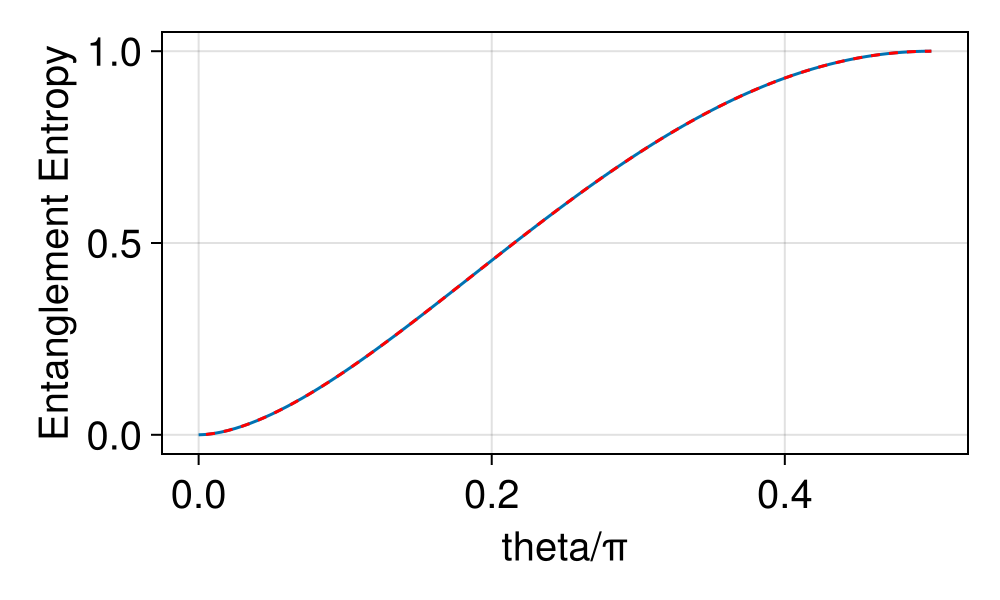

In [14]:
f = Figure(size=(500,300), fontsize=20)
Axis(f[1,1], xlabel="theta/π", ylabel="Entanglement Entropy")
lines!(thetas./pi, S, label="S(θ)")
lines!(thetas./pi, S_ana.(thetas), label="S_ana(θ)", linestyle=:dash, color=:red)
f